<a href="https://colab.research.google.com/github/Yascaram/Tech-Challange-Vin-cola-/blob/main/tech_sub1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exportação


=== MAIOR DESTINO NO TOTAL GERAL ACUMULADO ===
Top 1 em Volume: Estados Unidos com 135,022,125 Kg
Top 1 em Valor:  Japão com US$ 211,669,661.00

=== MAIOR DESTINO POR PRODUTO ===
[Vinhos de Mesa]
  Maior Volume: Paraguai (127,579,737 Kg)
  Maior Valor:  Paraguai (US$ 102,717,952.00)
[Espumantes]
  Maior Volume: Estados Unidos (3,971,386 Kg)
  Maior Valor:  Estados Unidos (US$ 11,213,027.00)
[Sucos de Uva]
  Maior Volume: Japão (95,350,472 Kg)
  Maior Valor:  Japão (US$ 203,839,305.00)


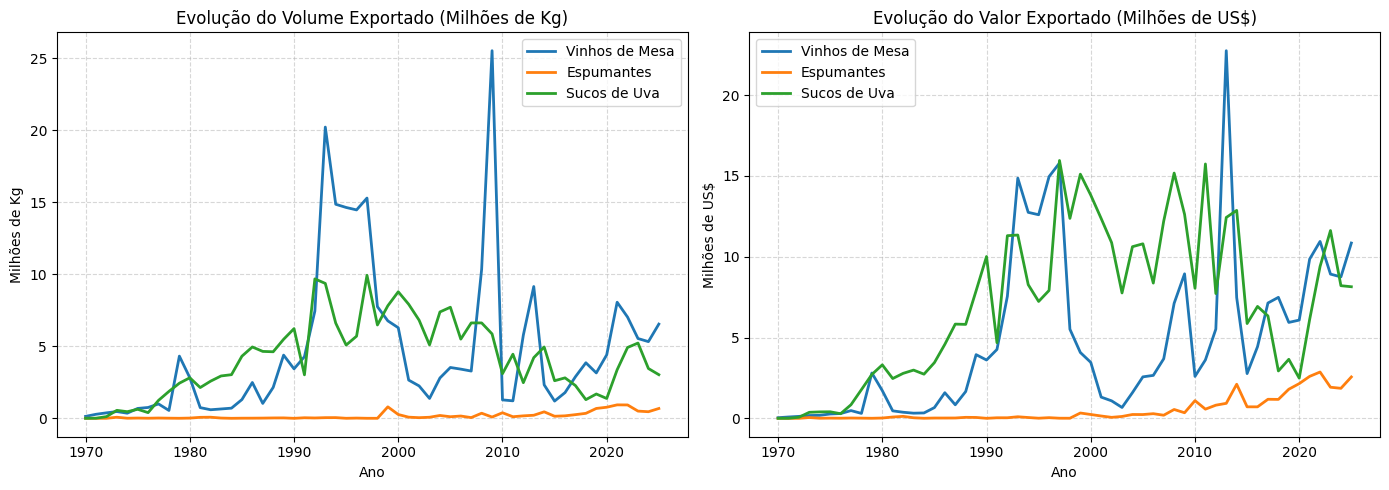


=== EXPORTAÇÕES NO ANO MAIS RECENTE (2025) ===
Espumantes: US$ 2,560,852.00 (683,060 Kg)
Sucos de Uva: US$ 8,142,080.00 (3,029,975 Kg)
Vinhos de Mesa: US$ 10,846,438.00 (6,540,975 Kg)
Total Geral (2025): US$ 21,549,370.00 (10,254,010 Kg)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def carregar_dados_exportacao(caminho, nome_produto):
    with open(caminho, 'r', encoding='latin1') as f:
        linhas = [l.strip().split('\t') for l in f if l.strip()]

    cabecalho = linhas[0]
    dados = linhas[1:]

    # Monta cabeçalhos alternados (Kg e US$)
    colunas = ['Id', 'Pais']
    for i in range(2, len(cabecalho), 2):
        ano = cabecalho[i]
        colunas.extend([f"{ano}_kg", f"{ano}_usd"])

    df = pd.DataFrame(dados, columns=colunas)

    # Conversão numérica
    for col in colunas[2:]:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Formato longo (tidy)
    cols_kg = [c for c in colunas if c.endswith('_kg')]
    cols_usd = [c for c in colunas if c.endswith('_usd')]

    df_kg = df[['Pais'] + cols_kg].melt(id_vars=['Pais'], var_name='Ano', value_name='Quantidade_Kg')
    df_kg['Ano'] = df_kg['Ano'].apply(lambda x: int(x.split('_')[0]))

    df_usd = df[['Pais'] + cols_usd].melt(id_vars=['Pais'], var_name='Ano', value_name='Valor_USD')
    df_usd['Ano'] = df_usd['Ano'].apply(lambda x: int(x.split('_')[0]))

    df_final = pd.merge(df_kg, df_usd, on=['Pais', 'Ano'])
    df_final['Produto'] = nome_produto
    return df_final

# 1. Carregamento dos dados
arquivos = {
    'Vinhos de Mesa': 'ExpVinho.csv',
    'Espumantes': 'ExpEspumantes.csv',
    'Sucos de Uva': 'ExpSuco.csv'
}

df_total = pd.concat([carregar_dados_exportacao(arq, prod) for prod, arq in arquivos.items()], ignore_index=True)

# Correção de caracteres acentuados
def corrigir_codificacao(texto):
    try:
        return texto.encode('latin1').decode('utf-8')
    except Exception:
        return texto

df_total['Pais'] = df_total['Pais'].apply(corrigir_codificacao)

# 2. Resposta 1: País com maior exportação
print("=== MAIOR DESTINO NO TOTAL GERAL ACUMULADO ===")
top_geral_kg = df_total.groupby('Pais')['Quantidade_Kg'].sum().sort_values(ascending=False).head(1)
top_geral_usd = df_total.groupby('Pais')['Valor_USD'].sum().sort_values(ascending=False).head(1)
print(f"Top 1 em Volume: {top_geral_kg.index[0]} com {top_geral_kg.values[0]:,.0f} Kg")
print(f"Top 1 em Valor:  {top_geral_usd.index[0]} com US$ {top_geral_usd.values[0]:,.2f}\n")

print("=== MAIOR DESTINO POR PRODUTO ===")
for prod in arquivos.keys():
    sub = df_total[df_total['Produto'] == prod]
    top_kg = sub.groupby('Pais')['Quantidade_Kg'].sum().sort_values(ascending=False).head(1)
    top_usd = sub.groupby('Pais')['Valor_USD'].sum().sort_values(ascending=False).head(1)
    print(f"[{prod}]")
    print(f"  Maior Volume: {top_kg.index[0]} ({top_kg.values[0]:,.0f} Kg)")
    print(f"  Maior Valor:  {top_usd.index[0]} (US$ {top_usd.values[0]:,.2f})")

# 3. Resposta 2: Tendência de exportação
tendencia = df_total.groupby(['Ano', 'Produto'])[['Quantidade_Kg', 'Valor_USD']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for prod in arquivos.keys():
    dados_prod = tendencia[tendencia['Produto'] == prod]
    axes[0].plot(dados_prod['Ano'], dados_prod['Quantidade_Kg'] / 1e6, label=prod, linewidth=2)
    axes[1].plot(dados_prod['Ano'], dados_prod['Valor_USD'] / 1e6, label=prod, linewidth=2)

axes[0].set_title('Evolução do Volume Exportado (Milhões de Kg)')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Milhões de Kg')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].set_title('Evolução do Valor Exportado (Milhões de US$)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Milhões de US$')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Resposta 3: Exportações no ano mais recente
ano_recente = df_total['Ano'].max()
print(f"\n=== EXPORTAÇÕES NO ANO MAIS RECENTE ({ano_recente}) ===")
recente = df_total[df_total['Ano'] == ano_recente].groupby('Produto')[['Quantidade_Kg', 'Valor_USD']].sum()
for prod, row in recente.iterrows():
    print(f"{prod}: US$ {row['Valor_USD']:,.2f} ({row['Quantidade_Kg']:,.0f} Kg)")
print(f"Total Geral ({ano_recente}): US$ {recente['Valor_USD'].sum():,.2f} ({recente['Quantidade_Kg'].sum():,.0f} Kg)")

Os Estados Unidos lideram em volume total acumulado (135.022.125 kg), enquanto o Japão lidera em valor total arrecadado (US$ 211.669.661) no conjunto dos três produtos ao longo de todo o período histórico.

Tendência da Exportação ao Longo dos Anos

Vinhos de Mesa: Histórico caracterizado por forte volatilidade e picos pontuais de remessa a granel. Registrou grandes saltos em 1993 (~20 milhões de kg) e o ápice em volume em 2009 (25,5 milhões de kg). Em faturamento, o ápice ocorreu em 2013 (US$ 22,7 milhões). Após retração entre 2014 e 2019, recuperou dinamismo a partir de 2020, consolidando faturamento na faixa de US$ 9 a 11 milhões anuais.

Espumantes: Trajetória de crescimento contínuo e acelerado a partir dos anos 2000. Saiu de volumes quase residuais (menos de 20 mil kg/ano nas décadas de 1970 e 1980) para atingir seu recorde em volume em 2021 (935.243 kg) e em valor em 2022 (US$ 2,87 milhões), sustentando patamares elevados acima de US$ 2,5 milhões em 2025.

Sucos de Uva: Grande protagonismo nas décadas de 1980 a 2000, alcançando seu ápice histórico em 1997 (9,93 milhões de kg e US$ 15,95 milhões). Após período de retração de volume na década de 2010, recuperou receita relevante a partir de 2021, gerando US$ 11,62 milhões em 2023 e mantendo-se estável acima de US$ 8,1 milhões em 2024 e 2025.

Valores de Exportação no Ano Mais Recente da Base (2025)

Vinhos de Mesa: US$ 10.846.438 (volume de 6.540.975 kg).

Espumantes: US$ 2.560.852 (volume de 683.060 kg).

Sucos de Uva: US$ 8.142.080 (volume de 3.029.975 kg).

Total em 2025: US$ 21.549.370 (volume total de 10.254.010 kg).

(Caso seja considerado o ano consolidado imediatamente anterior, 2024: Vinhos de Mesa: US$ 8.751.295; Espumantes: US$ 1.857.711; Sucos de Uva: US$ 8.207.392).

# Importação

=== MAIOR PAÍS IMPORTADOR NO TOTAL GERAL ===
Top 1 em Volume: Chile com 990,623,107 Kg
Top 1 em Valor:  Chile com US$ 2,633,416,971.00

=== MAIOR PAÍS IMPORTADOR POR PRODUTO ===
[Vinhos de Mesa]
  Maior Volume: Chile (981,053,253 Kg)
  Maior Valor:  Chile (US$ 2,610,178,367.00)
[Espumantes]
  Maior Volume: FranÃ§a (38,132,223 Kg)
  Maior Valor:  FranÃ§a (US$ 403,034,903.00)
[Sucos de Uva]
  Maior Volume: Argentina (27,961,581 Kg)
  Maior Valor:  Argentina (US$ 23,418,594.00)


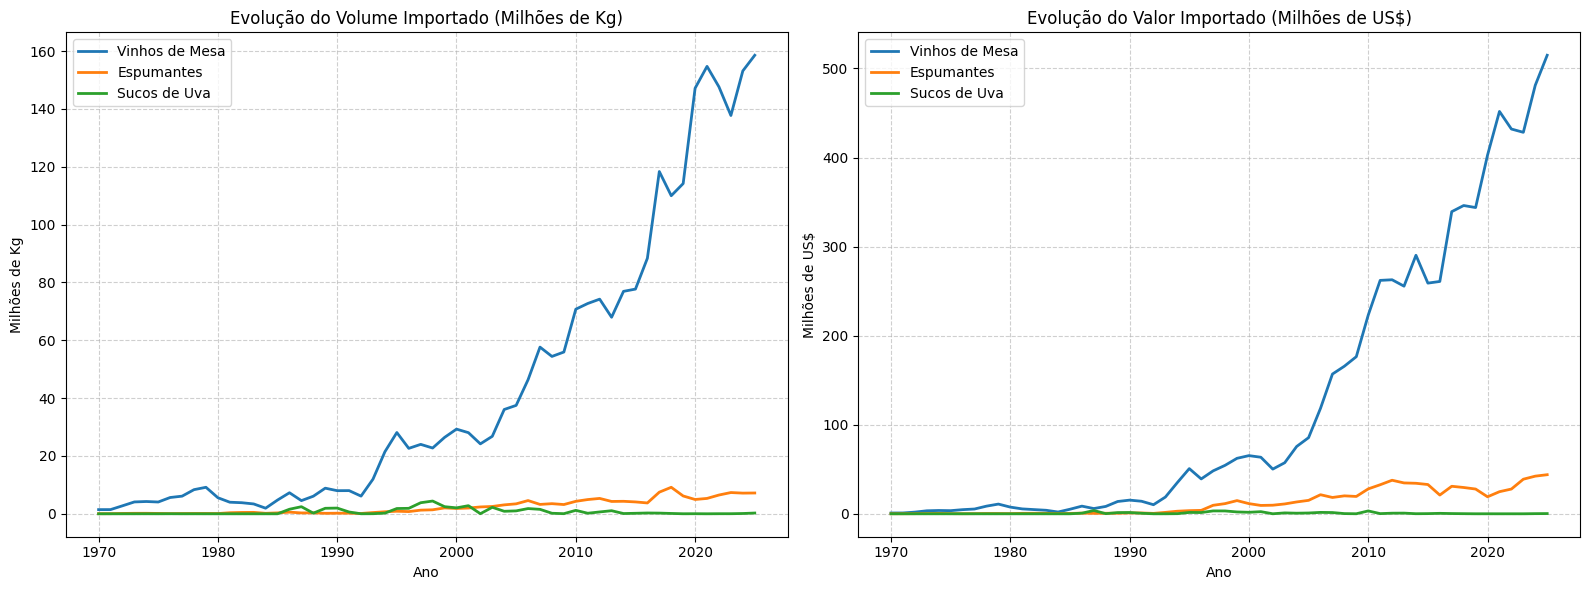

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def carregar_dados_embrapa(caminho, nome_produto):
    with open(caminho, 'r', encoding='latin1') as f:
        linhas = [linha.strip().split('\t') for linha in f if linha.strip()]

    cabecalho = linhas[0]
    dados = linhas[1:]

    # Mapear colunas duplicadas de ano (1ª = Kg/litro, 2ª = US$)
    colunas = ['Id', 'Pais']
    for i in range(2, len(cabecalho), 2):
        ano = cabecalho[i]
        colunas.extend([f"{ano}_kg", f"{ano}_usd"])

    df = pd.DataFrame(dados, columns=colunas)

    # Converter valores numéricos
    for col in colunas[2:]:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Reestruturar para formato longo (tidy)
    cols_kg = [c for c in colunas if c.endswith('_kg')]
    cols_usd = [c for c in colunas if c.endswith('_usd')]

    df_kg = df[['Pais'] + cols_kg].melt(id_vars=['Pais'], var_name='Ano', value_name='Quantidade_Kg')
    df_kg['Ano'] = df_kg['Ano'].apply(lambda x: int(x.split('_')[0]))

    df_usd = df[['Pais'] + cols_usd].melt(id_vars=['Pais'], var_name='Ano', value_name='Valor_USD')
    df_usd['Ano'] = df_usd['Ano'].apply(lambda x: int(x.split('_')[0]))

    df_final = pd.merge(df_kg, df_usd, on=['Pais', 'Ano'])
    df_final['Produto'] = nome_produto
    return df_final

# 1. Carregamento dos dados
arquivos = {
    'Vinhos de Mesa': 'ImpVinhos.csv',
    'Espumantes': 'ImpEspumantes.csv',
    'Sucos de Uva': 'ImpSuco.csv'
}

dfs = [carregar_dados_embrapa(arq, prod) for prod, arq in arquivos.items()]
df_total = pd.concat(dfs, ignore_index=True)

# 2. Resposta: País com maior importação
print("=== MAIOR PAÍS IMPORTADOR NO TOTAL GERAL ===")
top_geral_kg = df_total.groupby('Pais')['Quantidade_Kg'].sum().sort_values(ascending=False).head(1)
top_geral_usd = df_total.groupby('Pais')['Valor_USD'].sum().sort_values(ascending=False).head(1)
print(f"Top 1 em Volume: {top_geral_kg.index[0]} com {top_geral_kg.values[0]:,.0f} Kg")
print(f"Top 1 em Valor:  {top_geral_usd.index[0]} com US$ {top_geral_usd.values[0]:,.2f}\n")

print("=== MAIOR PAÍS IMPORTADOR POR PRODUTO ===")
for prod in arquivos.keys():
    sub = df_total[df_total['Produto'] == prod]
    top_kg = sub.groupby('Pais')['Quantidade_Kg'].sum().sort_values(ascending=False).head(1)
    top_usd = sub.groupby('Pais')['Valor_USD'].sum().sort_values(ascending=False).head(1)
    print(f"[{prod}]")
    print(f"  Maior Volume: {top_kg.index[0]} ({top_kg.values[0]:,.0f} Kg)")
    print(f"  Maior Valor:  {top_usd.index[0]} (US$ {top_usd.values[0]:,.2f})")

# 3. Tendência ao longo dos anos
tendencia = df_total.groupby(['Ano', 'Produto'])[['Quantidade_Kg', 'Valor_USD']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for prod in arquivos.keys():
    dados_prod = tendencia[tendencia['Produto'] == prod]
    axes[0].plot(dados_prod['Ano'], dados_prod['Quantidade_Kg'] / 1e6, label=prod, linewidth=2)
    axes[1].plot(dados_prod['Ano'], dados_prod['Valor_USD'] / 1e6, label=prod, linewidth=2)

axes[0].set_title('Evolução do Volume Importado (Milhões de Kg)')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Milhões de Kg')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].set_title('Evolução do Valor Importado (Milhões de US$)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Milhões de US$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

Categoria,Maior Importador (Volume - Kg),Maior Importador (Valor - US$)
Total Combinado,Chile (990.623.107 kg),Chile (US$ 2.633.416.971)
Vinhos de Mesa,Chile (981.053.253 kg),Chile (US$ 2.610.178.367)
Espumantes,França (38.132.223 kg),França (US$ 403.034.903)
Sucos de Uva,Argentina (27.961.581 kg),Argentina (US$ 23.418.594)

Tendência de Importação ao Longo dos Anos

Vinhos de Mesa: Apresenta forte tendência de crescimento contínuo e exponencial. De volumes inferiores a 2 milhões de kg nos anos 1970, ultrapassou 70 milhões de kg em 2010 e consolidou patamares superiores a 150 milhões de kg/ano nos anos 2020 (superando US$ 500 milhões anuais), representando a esmagadora maioria do mercado de importação vitivinícola brasileira.

Espumantes: Demonstra tendência ascendente moderada e constante, com aceleração a partir dos anos 2000. Saltou de menos de 100 mil kg na década de 1970/1980 para volumes entre 7 e 9 milhões de kg por ano recentemente, com destaque para vinhos e champanhes franceses, italianos e espanhóis de maior valor agregado.

Sucos de Uva: Registra tendência declinante e residual. Teve seus picos entre as décadas de 1980 e 1990 (atingindo o ápice em 1998 com 4,4 milhões de kg), reduzindo-se expressivamente a partir dos anos 2010 devido ao fortalecimento da indústria nacional de sucos integrais, mantendo volumes baixos e pontuais nos anos recentes.

# Produção


=== EVOLUÇÃO TEMPORAL DA PRODUÇÃO DE UVA ===
 ano  valor_mil_reais  valor_bilhoes_reais
2020        3627429.0             3.627429
2021        4266464.0             4.266464
2022        4533446.0             4.533446
2023        5611355.0             5.611355
2024        8335241.0             8.335241

Crescimento acumulado (2020–2024): 129.78%

=== PRINCIPAIS ESTADOS PRODUTORES EM 2024 ===
           estado  valor_milhoes_reais  participacao_pct
       Pernambuco             4310.441         51.713441
Rio Grande do Sul             1598.405         19.176466
            Bahia              945.225         11.340101
        São Paulo              875.746         10.506544
           Paraná              287.373          3.447686


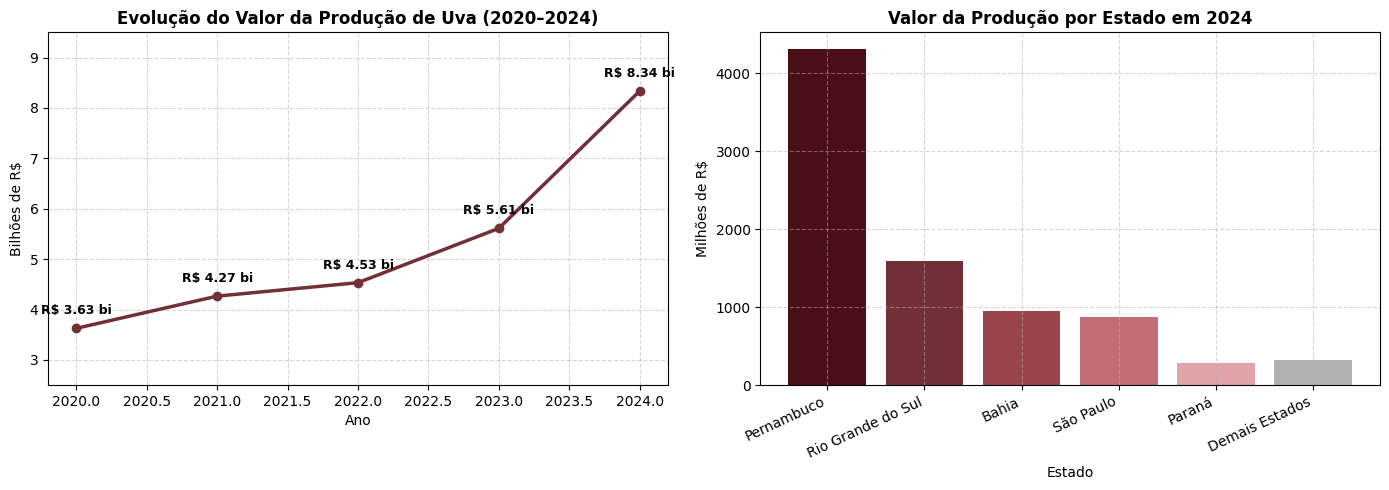

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregamento e limpeza da série histórica (2020 a 2024)
linhas_tempo = []
with open('uva-valor-da-produo-mil-reais.csv', 'r', encoding='latin1') as f:
    for linha in f:
        partes = [p.strip() for p in linha.strip().split(',')]
        if len(partes) >= 2 and partes[0].isnumeric():
            linhas_tempo.append({
                'ano': int(partes[0]),
                'valor_mil_reais': float(partes[1].replace('.', ''))
            })

df_tempo = pd.DataFrame(linhas_tempo)
df_tempo['valor_bilhoes_reais'] = df_tempo['valor_mil_reais'] / 1e6

# 2. Carregamento e limpeza da distribuição por estados (2024)
linhas_estados = []
with open('uva-valor-da-produo-2024.csv', 'r', encoding='latin1') as f:
    for linha in f:
        partes = [p.strip() for p in linha.strip().split(',')]
        if len(partes) >= 2 and partes[0] not in ['Uva - Valor da produÃ§Ã£o (2024)', 'localidade', 'Fonte: PAM', '']:
            estado = partes[0].encode('latin1').decode('utf-8')
            val_str = partes[1].replace('.', '').replace('-', '0')
            valor = float(val_str) if val_str.isnumeric() else 0.0
            linhas_estados.append({'estado': estado, 'valor_mil_reais': valor})

df_estados = pd.DataFrame(linhas_estados)
df_estados['valor_milhoes_reais'] = df_estados['valor_mil_reais'] / 1e3
df_estados['participacao_pct'] = (df_estados['valor_mil_reais'] / df_estados['valor_mil_reais'].sum()) * 100
df_estados = df_estados.sort_values(by='valor_mil_reais', ascending=False).reset_index(drop=True)

# 3. Estatísticas e conclusões
crescimento_acumulado = ((df_tempo.loc[df_tempo['ano'] == 2024, 'valor_mil_reais'].values[0] /
                          df_tempo.loc[df_tempo['ano'] == 2020, 'valor_mil_reais'].values[0]) - 1) * 100

print("=== EVOLUÇÃO TEMPORAL DA PRODUÇÃO DE UVA ===")
print(df_tempo[['ano', 'valor_mil_reais', 'valor_bilhoes_reais']].to_string(index=False))
print(f"\nCrescimento acumulado (2020–2024): {crescimento_acumulado:.2f}%")

print("\n=== PRINCIPAIS ESTADOS PRODUTORES EM 2024 ===")
print(df_estados[['estado', 'valor_milhoes_reais', 'participacao_pct']].head(5).to_string(index=False))

# 4. Geração dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolução Temporal
ax1.plot(df_tempo['ano'], df_tempo['valor_bilhoes_reais'], marker='o', color='#722F37', linewidth=2.5)
for _, row in df_tempo.iterrows():
    ax1.annotate(f"R$ {row['valor_bilhoes_reais']:.2f} bi", (row['ano'], row['valor_bilhoes_reais']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', fontsize=9)
ax1.set_title('Evolução do Valor da Produção de Uva (2020–2024)', fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Bilhões de R$')
ax1.set_ylim(2.5, 9.5)
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Top Estados em 2024
top_plot = df_estados.head(5)[['estado', 'valor_milhoes_reais']].copy()
outros = pd.DataFrame([{'estado': 'Demais Estados', 'valor_milhoes_reais': df_estados.iloc[5:]['valor_milhoes_reais'].sum()}])
top_plot = pd.concat([top_plot, outros], ignore_index=True)

cores = ['#4A0E17', '#722F37', '#99444B', '#C26D74', '#DFA3A8', '#B0B0B0']
ax2.bar(range(len(top_plot)), top_plot['valor_milhoes_reais'], color=cores)
ax2.set_title('Valor da Produção por Estado em 2024', fontweight='bold')
ax2.set_xlabel('Estado')
ax2.set_ylabel('Milhões de R$')
ax2.set_xticks(range(len(top_plot)))
ax2.set_xticklabels(top_plot['estado'], rotation=25, ha='right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

O cenário da vitivinicultura e da cadeia de derivados de uva no Brasil experimentou uma forte expansão econômica recente, mais que dobrando o valor da produção entre 2020 e 2024.

Visão Geral da Produção Nacional
Forte aceleração do valor de produção: O valor da produção de uva no Brasil saltou de R$ 3,63 bilhões em 2020 para R$ 8,34 bilhões em 2024, representando um crescimento acumulado de 129,8% no período. Apenas entre 2023 e 2024, a alta foi de 48,5%.

Concentração no Vale do São Francisco: Pernambuco lidera o valor da colheita nacional, somando R$ 4,31 bilhões em 2024 (51,7% do total do país), impulsionado pela alta tecnologia de irrigação e colheitas múltiplas destinadas a uvas de mesa e vinhos finos.

Polo tradicional de transformação (Vinhos, Espumantes e Sucos): O Rio Grande do Sul responde por R$ 1,60 bilhão (19,2% do valor), concentrando a maior parte do processamento industrial do país para espumantes, vinhos de mesa e sucos de uva integrais.

Outros polos relevantes: Bahia (R$ 945,2 milhões, 11,3%), São Paulo (R$ 875,7 milhões, 10,5%) e Paraná (R$ 287,4 milhões, 3,4%) completam o grupo dos cinco principais estados produtores.

# Clima


O clima é um dos elementos mais preponderantes para determinar a qualidade e a "tipicidade" das uvas e dos vinhos. Embora o texto foque especificamente em vinhos, essas características climáticas são a base para a excelência no cultivo da uva, impactando também a produção de sucos e derivados.

O estudo utiliza uma Classificação Climática Multicritério (CCM) que destaca três características fundamentais de um clima favorável:

Potencial Heliotérmico (Luz Solar e Calor): A disponibilidade de calor e radiação solar é essencial para o desenvolvimento da videira e a maturação das uvas. O calor adequado permite que as uvas acumulem os açúcares necessários para a fermentação ou para a doçura dos sucos.


Disponibilidade Hídrica Controlada: O excesso de chuvas durante a maturação e a colheita pode ser prejudicial. O documento aponta que as melhores safras (como analisado no caso da Serra Gaúcha) acontecem em anos com menor disponibilidade de água no solo e maior radiação solar. Um clima um pouco mais seco nessa fase final permite que a uva atinja melhores níveis de maturação e evita perdas por podridão.


Frio Noturno (Amplitude Térmica): A ocorrência de noites mais frias ou temperadas durante o período de maturação da uva é um ótimo indicativo. Essa queda de temperatura à noite ajuda a preservar a acidez natural e os aromas das uvas, equilibrando a doçura gerada pelo sol durante o dia.


Em termos geográficos, a maior parte da área mundial destinada à viticultura de qualidade está concentrada em regiões de clima temperado e clima mediterrâneo.

Serra Gaúcha: O Desafio da Umidade e a Força dos Espumantes
A Serra Gaúcha possui um clima classificado como úmido, temperado quente e de noites temperadas. É uma condição climática bastante particular se comparada à maioria das regiões vinícolas do mundo.
Vantagens para Brancos e Espumantes: O calor permite cultivar tanto uvas que amadurecem cedo quanto as mais tardias. A condição de clima úmido, embora pareça um obstáculo, é excelente para a produção de vinhos brancos e espumantes, pois ajuda a uva a manter uma acidez natural que valoriza muito esses produtos.
Desafios para os Tintos: Os verões úmidos dificultam o controle de doenças e o alcance da maturação perfeita para uvas tintas. Por isso, os vinhos tintos da região tendem a ter estrutura e aromas de nível fraco a médio, exigindo técnicas rigorosas de manejo no vinhedo para melhorar sua qualidade.
A Importância do "Efeito Safra": Como o calor e o sol são abundantes, o que realmente define se um ano terá uma safra excepcional na Serra Gaúcha é a chuva. As melhores safras ocorrem nos anos em que chove menos e há mais radiação solar, permitindo que a uva amadureça sem apodrecer e seja colhida no momento exato.
Microclimas (Topoclimas): A região é cheia de vales, encostas e diferentes altitudes. Isso cria pequenos "microclimas" dentro da própria serra, fazendo com que videiras plantadas a poucos quilômetros de distância produzam vinhos com características totalmente distintas.

Vale do Submédio São Francisco: A Viticultura Tropical
Localizada no Nordeste brasileiro, essa região possui um clima tropical semiárido, o que a torna uma exceção absoluta no mundo tradicional do vinho.
Várias Safras no Ano: A disponibilidade de calor e luz do sol é tão alta e constante que as videiras não entram em dormência natural pelo frio, permitindo que os produtores colham mais de uma safra por ano.
"Clima sob Medida" (Variabilidade intra-anual): Em vez de ficar refém das quatro estações bem definidas, a região alterna basicamente entre uma estação úmida e uma seca. Isso confere um superpoder aos viticultores: eles podem escolher em qual período do ano vão podar e irrigar a planta para que ela dê frutos.
Estratégia de Produção: Essa flexibilidade permite que os produtores evitem os meses chuvosos (reduzindo doenças nas plantas), adaptem o ciclo às exigências de cada tipo de uva e até programem a colheita para épocas em que o mercado paga mais pelo produto.
Em resumo, enquanto a Serra Gaúcha brilha pela acidez de seus espumantes e depende muito de anos mais secos para safras tintas excepcionais, o Vale do São Francisco usa o calor constante e a irrigação controlada para produzir o ano inteiro em um ritmo totalmente ditado pelo viticultor.


fonte: https://www.alice.cnptia.embrapa.br/alice/bitstream/doc/1049663/1/toniettocbve9.pdf